<a href="https://colab.research.google.com/github/AhnafAhmed29/Data-Science-Project/blob/main/CSE366(Ahnaf_Ahmed).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Project: CSE303 - statistics for datascience
(Brain Tumor MRI Dataset)
members:
* Ahnaf Ahmed(2022-3-60-151)
* Mosharof Hossain (2022-3-60-070)
* Rebeka Sultana Dina (2022-3-60-027)



### **Library Imports**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import tensorflow as tf
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.models import Sequential
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

### **Dataset Setup**

In [3]:
import kagglehub
masoudnickparvar_brain_tumor_mri_dataset_path = kagglehub.dataset_download('masoudnickparvar/brain-tumor-mri-dataset')

print('Data source import complete.')


Data source import complete.


In [4]:
path = '/kaggle/input/brain-tumor-mri-dataset'
print(os.listdir(path))

['Training', 'Testing']


In [5]:
df_train = os.path.join(path ,'Training')
df_test = os.path.join(path, 'Testing')

### **Image Generators**

In [6]:
img_size = 224
bat_size = 32

In [7]:
train_generator = tf.keras.utils.image_dataset_from_directory(
    df_train,
    labels="inferred",
    image_size=(img_size, img_size),
    batch_size=bat_size,
    color_mode="grayscale",
    shuffle=True,
    validation_split=0.2,
    subset="training",
    seed=42
)

classes = train_generator.class_names
print(f"{classes}")

Found 5712 files belonging to 4 classes.
Using 4570 files for training.
['glioma', 'meningioma', 'notumor', 'pituitary']


Image counts per class: {'pituitary': 1457, 'notumor': 1595, 'meningioma': 1339, 'glioma': 1321}


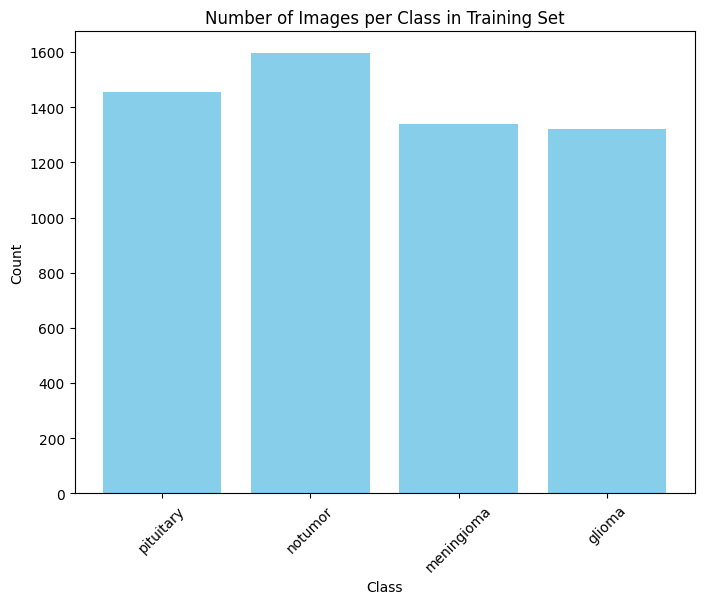

In [8]:
# Path of training dataset
train_path = df_train

# Count images in each class
class_counts = {}
for class_name in os.listdir(train_path):
    class_folder = os.path.join(train_path, class_name)
    if os.path.isdir(class_folder):
        class_counts[class_name] = len(os.listdir(class_folder))

print("Image counts per class:", class_counts)

plt.figure(figsize=(8,6))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.title("Number of Images per Class in Training Set")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [9]:
validation_generator = tf.keras.utils.image_dataset_from_directory(
    df_train,
    labels="inferred",
    image_size=(img_size, img_size),
    batch_size=bat_size,
    color_mode="grayscale",
    validation_split=0.2,
    subset="validation",
    seed=42
)

test_generator = tf.keras.utils.image_dataset_from_directory(
        df_test ,
        labels = "inferred",
        image_size=(img_size, img_size),
        batch_size=bat_size,
        color_mode='grayscale'
)

Found 5712 files belonging to 4 classes.
Using 1142 files for validation.
Found 1311 files belonging to 4 classes.


### **Visualizing Samples & Normalization**

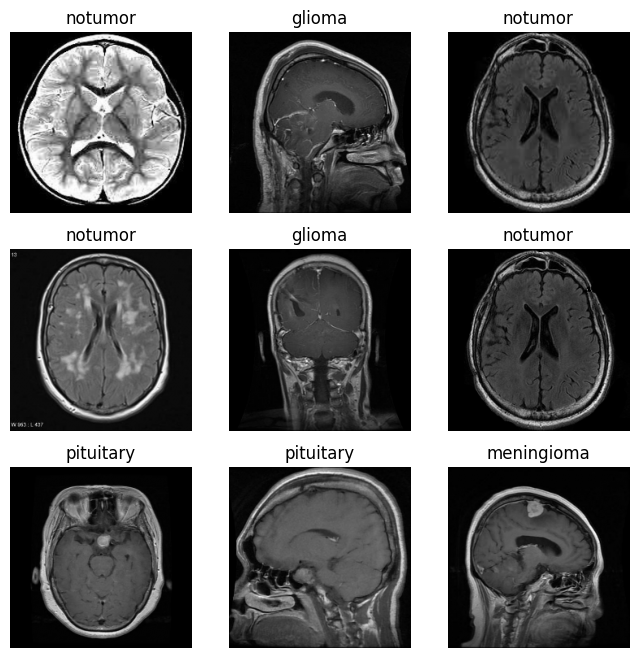

In [10]:
plt.figure(figsize=(8, 8))
for images , labels in train_generator.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8') , cmap = 'gray')
        plt.title(classes[labels[i]])
        plt.axis('off')
    plt.show()

In [11]:
train_generator = train_generator.map(lambda x,y : (x/255,y))
validation_generator = validation_generator.map(lambda x,y : (x/255,y))
test_generator = test_generator.map(lambda x,y : (x/255,y))

### **CNN Model Architecture**

In [12]:
model = Sequential([
    Conv2D(32 , (3,3) , activation = 'relu' , input_shape = (img_size, img_size, 1)),
    MaxPooling2D((2,2)),
    Conv2D(64 , (3,3) , activation = 'relu'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128 , (3,3) , activation = 'relu'),
    MaxPooling2D((2,2)),
    Conv2D(256 , (3,3) , activation = 'relu'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(classes), activation='softmax')

])


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,107,076 (19.48 MB)

 Trainable params: 5,107,076 (19.48 MB)

 Non-trainable params: 0 (0.00 B)

### **Compilation & Training**

In [13]:
history = model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy'])

In [14]:
epochs = 20

model.fit(
    train_generator,
    epochs = epochs,
    validation_data = validation_generator
    )

Epoch 1/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 552s 4s/step - accuracy: 0.5630 - loss: 0.9844 - val_accuracy: 0.7767 - val_loss: 0.5728
Epoch 2/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 557s 4s/step - accuracy: 0.8126 - loss: 0.4835 - val_accuracy: 0.8713 - val_loss: 0.3509
Epoch 3/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 541s 4s/step - accuracy: 0.8758 - loss: 0.3258 - val_accuracy: 0.8932 - val_loss: 0.3187
Epoch 4/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 537s 4s/step - accuracy: 0.9137 - loss: 0.2427 - val_accuracy: 0.8879 - val_loss: 0.3387
Epoch 5/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 541s 4s/step - accuracy: 0.9322 - loss: 0.1839 - val_accuracy: 0.9089 - val_loss: 0.2756
Epoch 6/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 541s 4s/step - accuracy: 0.9460 - loss: 0.1406 - val_accuracy: 0.9203 - val_loss: 0.2934
Epoch 7/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 542s 4s/step - accuracy: 0.9607 - loss: 0.1130 - val_accuracy: 0.9238 - val_loss: 0.2871
Epoch 8/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 559s 4s/step - accuracy: 0.9669 - loss: 0.0906 - val_accu

### **Model Evaluation & Confusion Matrix**

In [15]:
loss , accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9527 - loss: 0.3141
Test Loss: 0.3279993534088135, Test Accuracy: 0.9466056227684021


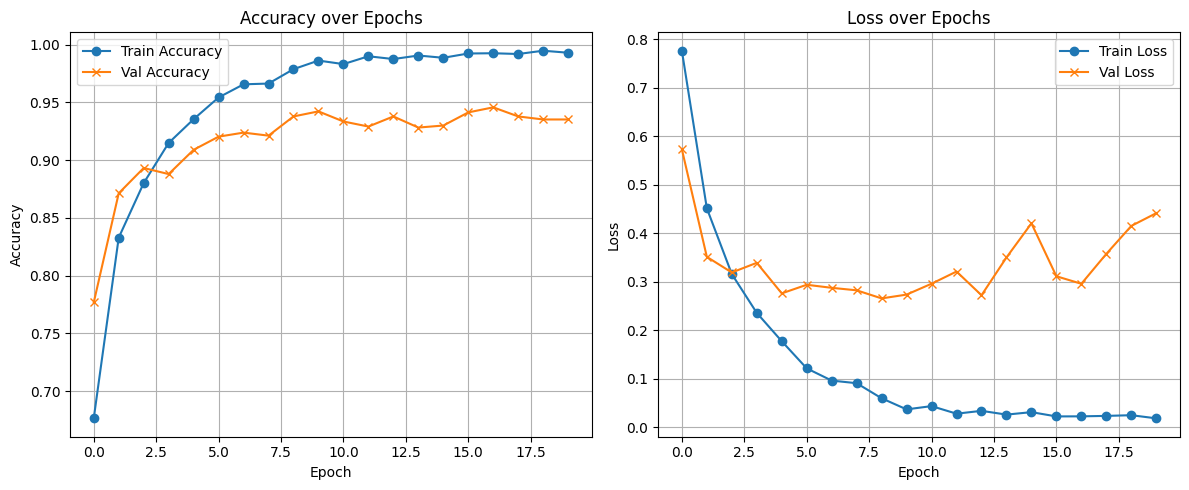

In [17]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(model.history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(model.history.history['val_accuracy'], label='Val Accuracy', marker='x')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(model.history.history['loss'], label='Train Loss', marker='o')
plt.plot(model.history.history['val_loss'], label='Val Loss', marker='x')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [18]:
y_true = []
images = []
for image, label in test_generator:
    y_true.extend(label.numpy())
    images.extend(image.numpy())

In [19]:
y_pred = model.predict(np.array(images))

41/41 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step


In [20]:
y_pred = np.argmax(y_pred, axis=1)

<Axes: >

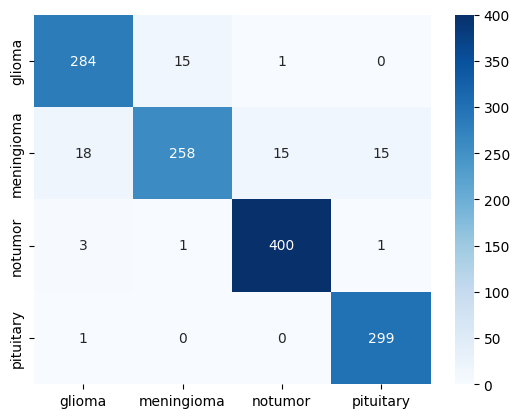

In [21]:
sns.heatmap(confusion_matrix(y_true, y_pred) , annot=True, fmt='d', cmap='Blues',xticklabels=classes, yticklabels=classes)

In [22]:
print(classification_report(y_true, y_pred, target_names=classes))

              precision    recall  f1-score   support

      glioma       0.93      0.95      0.94       300
  meningioma       0.94      0.84      0.89       306
     notumor       0.96      0.99      0.97       405
   pituitary       0.95      1.00      0.97       300

    accuracy                           0.95      1311
   macro avg       0.95      0.94      0.94      1311
weighted avg       0.95      0.95      0.95      1311



### **Single Image Prediction**

In [23]:
img_path = r'/kaggle/input/brain-tumor-mri-dataset/Testing/glioma/Te-glTr_0002.jpg'

In [27]:
def prediction(img_path):
    img = tf.keras.utils.load_img(img_path, color_mode='grayscale', target_size=(img_size, img_size))
    img = tf.keras.utils.img_to_array(img)
    img = np.expand_dims(img, axis=0) / 255.0
    predictions = model.predict(img)
    predicted_class = np.argmax(predictions[0])
    print(f"Predicted probabilities: {np.max(predictions[0])*100:.2f}% for {classes[predicted_class]}")

    sns.barplot(x=classes, y=predictions[0], palette= 'Set3')

    plt.xlabel('Classes')
    plt.ylabel('Probability')
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicted probabilities: 99.67% for glioma


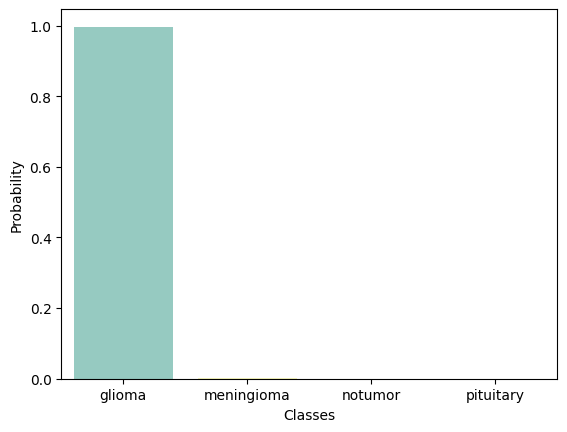

In [28]:
prediction(img_path)

In [35]:
img_path1 = r'/kaggle/input/brain-tumor-mri-dataset/Testing/notumor/Te-noTr_0002.jpg'

In [36]:
def prediction(img_path1):
    img = tf.keras.utils.load_img(img_path1, color_mode='grayscale', target_size=(img_size, img_size))
    img = tf.keras.utils.img_to_array(img)
    img = np.expand_dims(img, axis=0) / 255.0
    predictions = model.predict(img)
    predicted_class = np.argmax(predictions[0])
    print(f"Predicted probabilities: {np.max(predictions[0])*100:.2f}% for {classes[predicted_class]}")

    sns.barplot(x=classes, y=predictions[0], palette= 'Set3')

    plt.xlabel('Classes')
    plt.ylabel('Probability')
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted probabilities: 99.97% for notumor


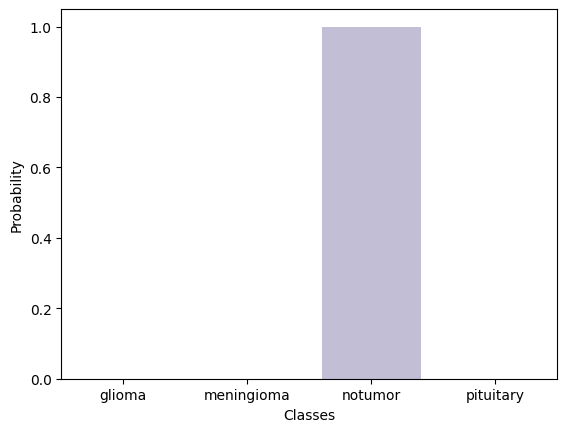

In [37]:
prediction(img_path1)